# ***概率论***

In [22]:
%matplotlib inline
import torch
from torch.distributions import multinomial      #multinomial就是“按给定的概率做随机抽签”的工具
import matplotlib.pyplot as plt

In [14]:
fair_probs = torch.ones([6]) / 6      #创建长度为6的一维数组，初始值全部为1，除以6表示每个类别的概率
multinomial.Multinomial(1 , fair_probs).sample()   #1表示实验总次数，即抽取一次

tensor([1., 0., 0., 0., 0., 0.])

上述这个例子模拟了一个离散均匀分布例子（六面骰子模型），第一段fair_probs用来创建每一个类别的概率，第二段模拟抽取的过程，Multinomial传入两个参数，第一个表示试验总次数，即只抽取一次，第二个参数传入每个类别的概率，.sample()方法从这个分布中抽取一个样本，然后返回一个和fair_probs一样的张量（长度为6），由于试验总次数为1,所以恰好只有一个位置为1（表示这个位置对应的类别被抽中一次）,其余位置均为0（未被抽中）

In [15]:
multinomial.Multinomial(7 , fair_probs).sample()   #修改参数为7

tensor([4., 2., 0., 0., 0., 1.])

所以在这里我们可以看到，当把试验总次数改为7时，返回的张量元素之和为7,表示每次实验抽中一个类别，一共抽到7个（包含相同类别，为有放回抽取模型）

下面我们可以通过这个实验来得出一些结论，比如大数定理

In [16]:
counts1 = multinomial.Multinomial(100 , fair_probs).sample()
print(counts1 / 100)
counst2 = multinomial.Multinomial(10000 , fair_probs).sample()
print(counst2 / 10000)

tensor([0.1600, 0.1500, 0.1600, 0.2400, 0.1500, 0.1400])
tensor([0.1707, 0.1684, 0.1674, 0.1655, 0.1630, 0.1650])


理论上按照公平的投骰子游戏得出的结论应该是每个类别6分之1的概率，我们目前分别进行了100次和10000次实验，发现试验次数越多越接近理论值

当然，我们也可以进行另外一个更加直观的实验

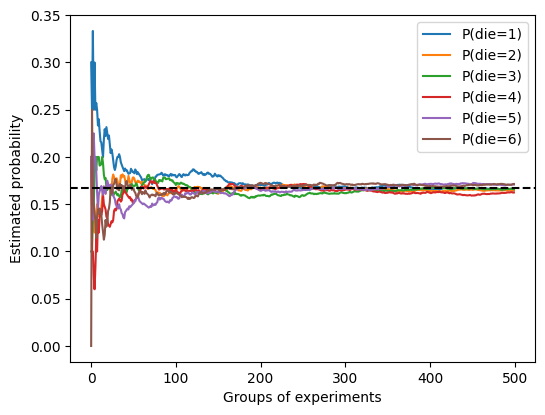

In [ ]:
counts = multinomial.Multinomial(10 , fair_probs).sample((500 , ))  #每次实验投掷10次骰子，一共进行500次实验
cum_counts = counts.cumsum(dim = 0)   #dim=0表示沿着0轴即沿着行自上而下累积，counts.cumsum记录每一次累积的中间过程
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)   #dim=1表示对每一行（同一组试验内的6个面）求和。
#可视化图像绘制
plt.figure(figsize=(6, 4.5))    # 设置图形尺寸
for i in range(6):
    plt.plot(estimates[:, i].numpy(), label=f"P(die={i+1})")  #在图中画出一条曲线，横坐标是组数（0~499），纵坐标是该面（1-6）的估计概率。
plt.axhline(y=0.167, color='black', linestyle='dashed')  # 理论概率线，在纵坐标y=0.167处画一条水平虚线。
plt.xlabel('Groups of experiments')   #设置 x 轴的标签为 "Groups of experiments"（实验组数）
plt.ylabel('Estimated probability')   #设置 y 轴的标签为 "Estimated probability"（估计概率）
plt.legend()  #显示图例，即每条曲线对应的标签（骰子面编号）
plt.show()   #将绘制好的图形显示在屏幕上    

对 `estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)` 的解释：
**`cum_counts.sum(dim=1, keepdims=True)`** 的含义：
- `cum_counts` 存的是每个面的“部分和”，`cum_counts.sum(dim=1)` 是把这些部分和加起来，得到所有面的“总次数”。
- `dim=1` 表示对每一行（同一组试验内的6个面）求和。
- 因为 `cum_counts` 每一行是到当前组为止的累积总次数，所以行内求和就是到当前组为止的总投掷次数。
- 总投掷次数 =（组数 × 10）。例如第0行总次数=10，第1行总次数=20，……第499行总次数=5000。
- `keepdims=True` 保持维度为 `(500, 1)`，方便后续广播除法。
- 除法：`cum_counts`（每个面的累积次数）除以总投掷次数 → 得到累积频率，即估计的概率。
- 结果：`estimates` 形状 `(500, 6)`。
- 含义：`estimates[i, j]` = 经过前 `i+1` 组试验（共 `(i+1)*10` 次投掷）后，第 `j+1` 面出现的比例。  
理论上，随着 `i` 增大，这个比例应该越来越接近 `1/6 ≈ 0.1667`。